###**DIP Practical-12**

**Name:** Yesha Pandya

**Enrollment Number:** 23BT04175

**Div:** 1 **Batch:** C

**Objective:**

Demonstrate use of DWT In Image Compression and Feature Selection.

Discrete Wavelet Transform breaks an image down into four distinct sub-bands. The LL band holds the low-frequency approximation, which basically looks like a blurry original image. Meanwhile, the LH, HL, and HH bands capture the high-frequency details across horizontal, vertical, and diagonal directions.

**1. Import libraries and image**

In [ ]:
#import libraries needed
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import pywt

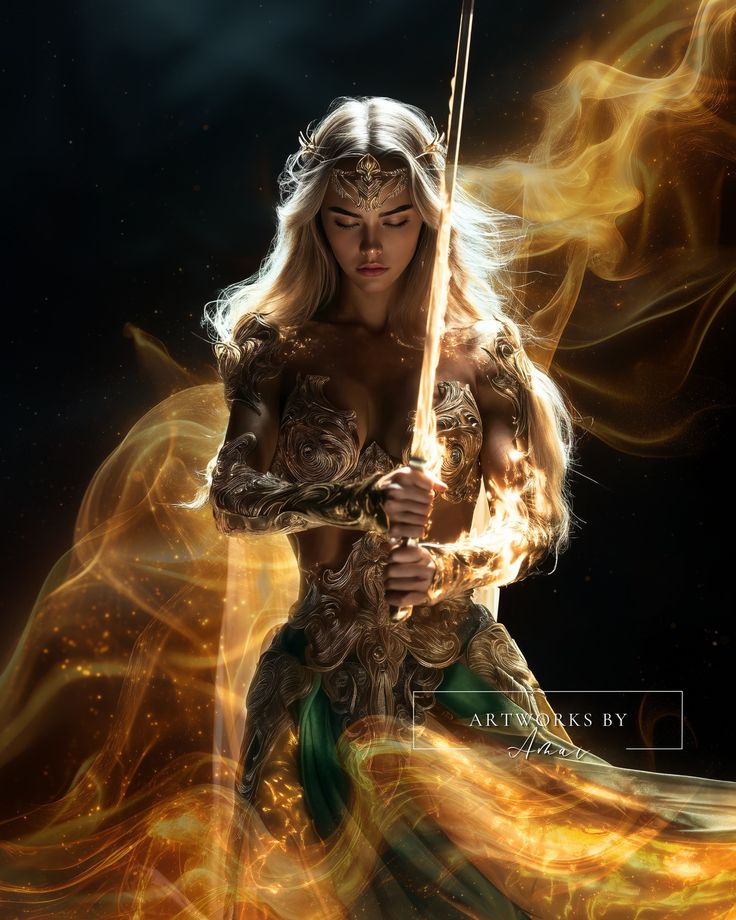

In [ ]:
#load and show original image
img=cv2.imread('aelin.jpeg')
cv2_imshow(img)

**Pre-req: convert image to grayscale**

DWT is easier to visualize on a single channel

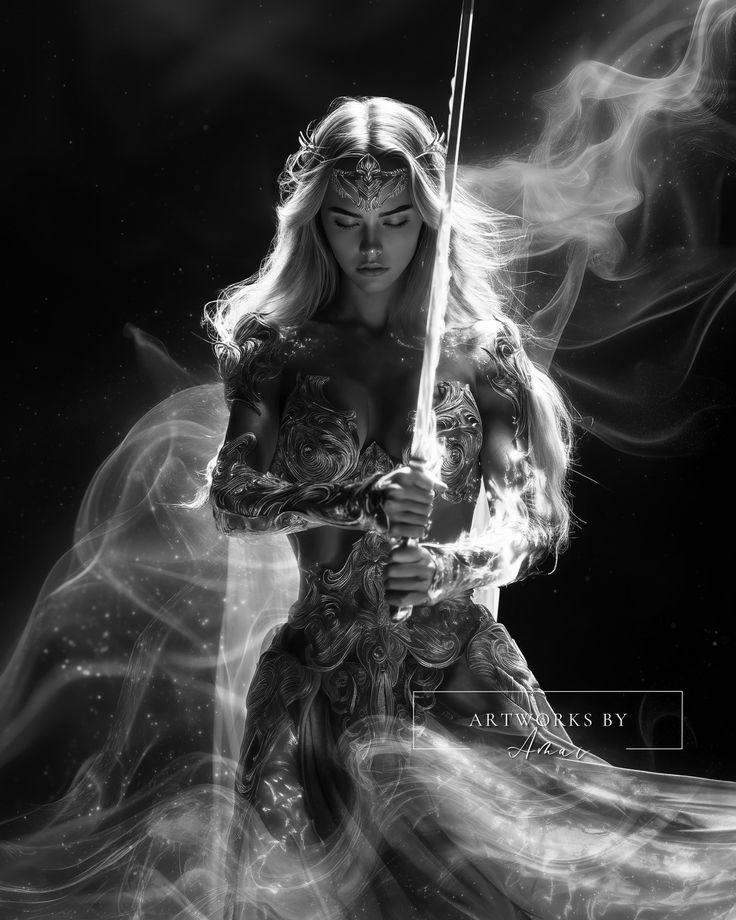

In [ ]:
#convert to grayscale
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)


 DWT level 1 decomposition:


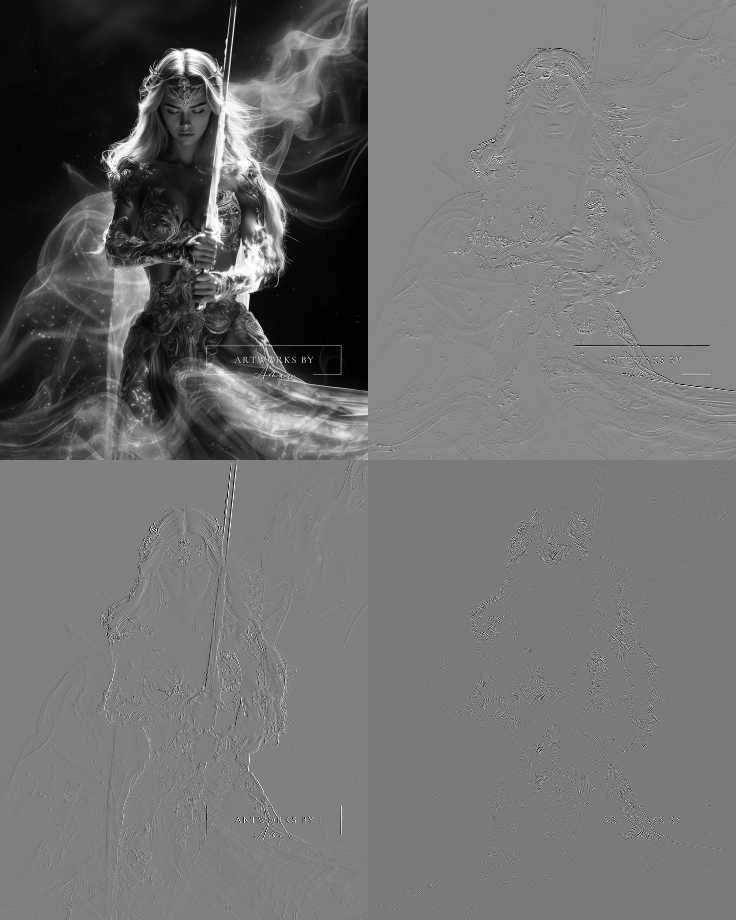

In [ ]:
# perform 2d discrete wavelet transform using the haar wavelet
coeffs2 = pywt.dwt2(gray, 'haar')
LL, (LH, HL, HH) = coeffs2

# normalize the matrices so they display correctly on screen
def normalize(matrix):
    # scale values to fit between 0 and 255
    matrix_normalized = cv2.normalize(matrix, None, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(matrix_normalized)

# prepare the sub-bands for visualization
ll_disp = normalize(LL)
lh_disp = normalize(LH)
hl_disp = normalize(HL)
hh_disp = normalize(HH)

# stitch the bands together to show the classic dwt layout
top_row = np.hstack((ll_disp, lh_disp))
bottom_row = np.hstack((hl_disp, hh_disp))
dwt_grid = np.vstack((top_row, bottom_row))

print("\n DWT level 1 decomposition:")
cv2_imshow(dwt_grid)

### **Image Compression using DWT**

Compression works by discarding the least important visual information. The high-frequency bands (LH, HL, HH) mostly contain noise or extremely fine textures, so we can safely threshold them to zero without ruining the picture. After zeroing out these minor details, we apply the Inverse Discrete Wavelet Transform (IDWT). The reconstructed image visually loses some of the sharpest sparks and armor scratches.

--- original vs compressed image ---


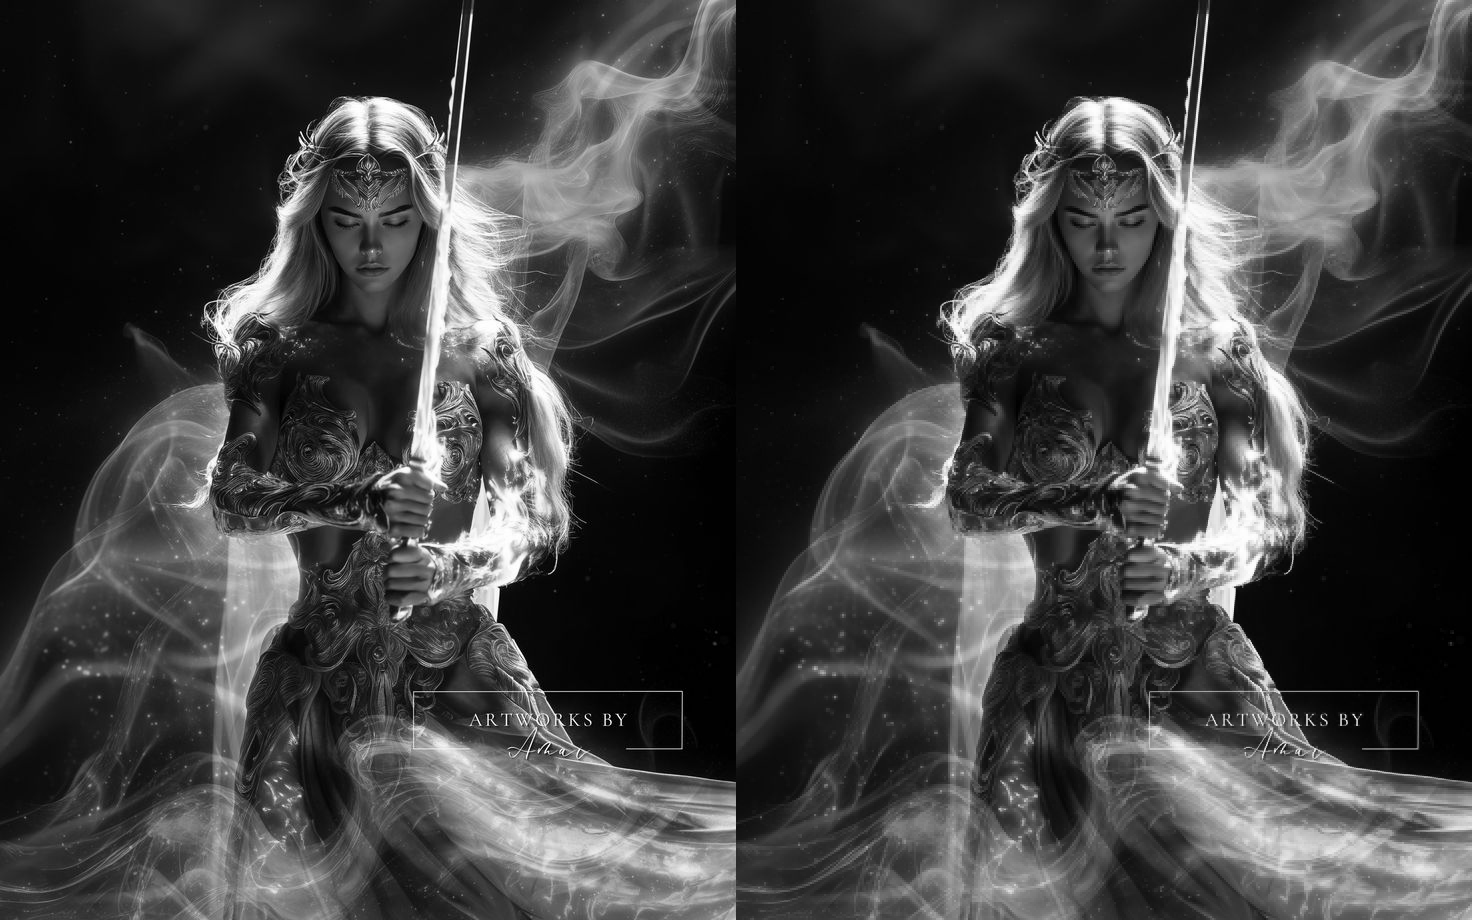

In [ ]:
# set a threshold value to zero out the less important high-frequency details
threshold = 30

# apply soft thresholding to the detail coefficients
# this essentially compresses the image data by removing weak signals
LH_thresh = pywt.threshold(LH, threshold, mode='soft')
HL_thresh = pywt.threshold(HL, threshold, mode='soft')
HH_thresh = pywt.threshold(HH, threshold, mode='soft')

# reconstruct the image using the modified coefficients
coeffs_compressed = (LL, (LH_thresh, HL_thresh, HH_thresh))
img_reconstructed = pywt.idwt2(coeffs_compressed, 'haar')

# clean up the data type for display
img_reconstructed = np.uint8(np.clip(img_reconstructed, 0, 255))

print("--- original vs compressed image ---")
# place them side by side to compare the lost details in the sparks
combined = np.hstack((gray, img_reconstructed))
cv2_imshow(combined)

### **Feature Selection using DWT**

Sometimes we prioritize structural outlines over the base colors. By ignoring the LL approximation band completely, we isolate the sharp geometric features of the sword and character. We combine the horizontal, vertical, and diagonal sub-bands to extract a strong texture map. This technique is incredibly useful for machine learning models, as they can process the glowing edges without being distracted by background shading.

Selected high-frequency features:


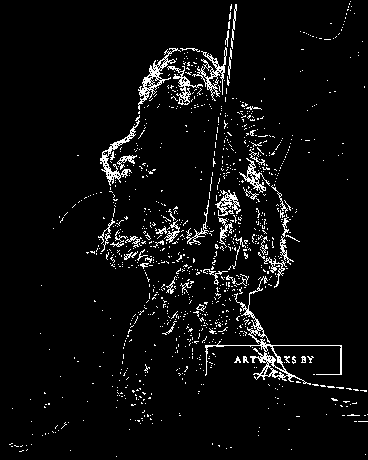

In [ ]:
# calculate the magnitude of the high frequency features
# we square the detail bands, add them, and take the square root
feature_map = np.sqrt(LH**2 + HL**2 + HH**2)

# normalize the feature map for clear viewing
feature_map_disp = normalize(feature_map)

# apply a binary threshold to isolate the strongest features
# pixels above 50 become pure white, highlighting the sharpest armor edges
_, feature_binary = cv2.threshold(feature_map_disp, 50, 255, cv2.THRESH_BINARY)

print("Selected high-frequency features:")
cv2_imshow(feature_binary)